In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [2]:
# Download necessary NLTK data (run once)
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Diluni_128033\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Diluni_128033\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [10]:
df = pd.read_csv("C://Users//Diluni_128033//reqsys//data//Pure_Annotate_Dataset.csv", encoding='latin1')

In [11]:
print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (11440, 5)


,id,sentence,security,reliability,NFR_boolean
0,CCHIT Certified 2011 Ambulatory EHR Criteria 2...,The system shall create a single patient recor...,0,0,0
1,CCHIT Certified 2011 Ambulatory EHR Criteria 2...,The system shall associate (store and link) ke...,0,0,0
2,CCHIT Certified 2011 Ambulatory EHR Criteria 2...,The system shall provide the ability to store ...,0,0,0
3,CCHIT Certified 2011 Ambulatory EHR Criteria 2...,The system shall provide a field which will id...,0,0,0
4,CCHIT Certified 2011 Ambulatory EHR Criteria 2...,The system shall provide the ability to merge ...,0,0,0


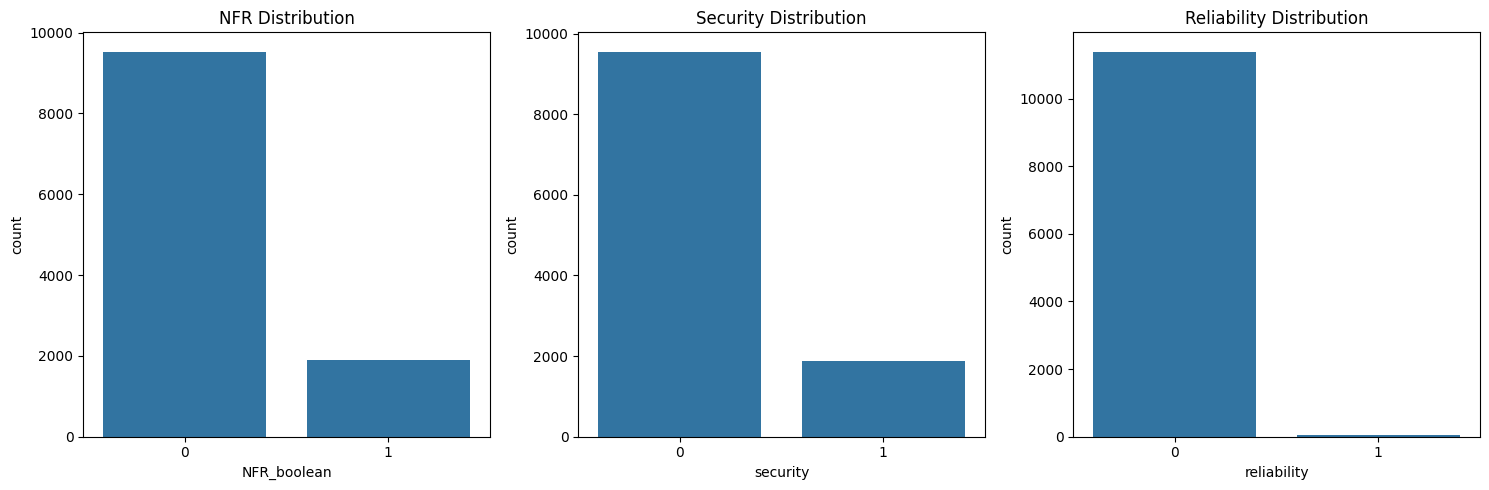

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.countplot(x='NFR_boolean', data=df, ax=axes[0]).set_title('NFR Distribution')
sns.countplot(x='security', data=df, ax=axes[1]).set_title('Security Distribution')
sns.countplot(x='reliability', data=df, ax=axes[2]).set_title('Reliability Distribution')
plt.tight_layout()
plt.savefig('label_distributions.png')

In [13]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

In [14]:
def clean_text(text):
    # Convert to lowercase
    text = str(text).lower()
    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    # Remove stopwords and lemmatize
    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return ' '.join(words)

In [16]:
df['cleaned_sentence'] = df['sentence'].apply(clean_text)

In [17]:
display(df[['sentence', 'cleaned_sentence']].head())

,sentence,cleaned_sentence
0,The system shall create a single patient recor...,system shall create single patient record patient
1,The system shall associate (store and link) ke...,system shall associate store link key identifi...
2,The system shall provide the ability to store ...,system shall provide ability store one identif...
3,The system shall provide a field which will id...,system shall provide field identify patient ex...
4,The system shall provide the ability to merge ...,system shall provide ability merge patient inf...


In [18]:
df.to_csv('Preprocessed_Dataset.csv', index=False)
print("Saved preprocessed data to 'Preprocessed_Dataset.csv'")

Saved preprocessed data to 'Preprocessed_Dataset.csv'
